# Лабораторная работа №5: «Анализ последовательностей»
**Цель работы:** Освоить методы поиска последовательных шаблонов (AprioriAll, PrefixSpan), реализовать базовые алгоритмы, применить их к реальным транзакционным данным датасета Online Retail и оценить их эффективность.

**Датасет**: Online Retail II (транзакции интернет-магазина за 2009-2011 гг.).

Подготовка окружения и загрузка датасета
В этой ячейке мы отключим предупреждения, настроим интерактивное отображение графиков и загрузим файл исходного датасета online_retail_II.xlsx.

In [3]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
from google.colab import files
print("Загрузите файл online_retail_II.xlsx")
uploaded = files.upload()

Загрузите файл online_retail_II.xlsx


Saving online_retail_II.xlsx to online_retail_II (1).xlsx


In [8]:
!pip install prefixspan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import time
from collections import defaultdict
from itertools import combinations
from prefixspan import PrefixSpan

# Настройки графиков
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEED = 42
np.random.seed(SEED)
print("Все библиотеки успешно загружены.")

Все библиотеки успешно загружены.


In [9]:
file_name = list(uploaded.keys())[0]
raw_data = pd.read_excel(file_name)
print(f"Исходный размер данных: {raw_data.shape}")
raw_data.head()

Исходный размер данных: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Предобработка и фильтрация данных
Выполним предварительную очистку:

Удалим отмененные транзакции (чеки с префиксом 'C').

Исключим записи без ID клиента или описания товара.

Отфильтруем невалидные количества и цены (меньше либо равные 0).

Ограничимся ТОП-50 самыми популярными товарами для оптимизации времени вычислений.

In [10]:
data = raw_data.copy()
data['Invoice'] = data['Invoice'].astype(str)
data = data[~data['Invoice'].str.startswith('C')]
data = data.dropna(subset=['Customer ID', 'Description'])
data = data[(data['Quantity'] > 0) & (data['Price'] > 0)]
data['Customer ID'] = data['Customer ID'].astype(int)

# Фильтрация по TOP-50 товарам
TOP = 50
top_products = data['Description'].value_counts().head(TOP).index.tolist()
data = data[data['Description'].isin(top_products)]

print(f"После очистки: {data.shape}")
print(f"Уникальных покупателей: {data['Customer ID'].nunique()}")
print(f"Уникальных товаров: {data['Description'].nunique()}")
print(f"Временной интервал: {data['InvoiceDate'].min()} – {data['InvoiceDate'].max()}")

После очистки: (48541, 8)
Уникальных покупателей: 3684
Уникальных товаров: 50
Временной интервал: 2009-12-01 07:45:00 – 2010-12-09 20:01:00


In [11]:
def create_sequences(df):
    """
    Преобразует DataFrame в словарь:
    customer_id -> [(время транзакции, frozenset(товары)), ...]
    """
    sequences = {}
    for cust_id, group in df.groupby('Customer ID'):
        transactions = []
        for inv_id, inv_group in group.groupby('Invoice'):
            dt = inv_group['InvoiceDate'].min()
            products = frozenset(inv_group['Description'].unique())
            transactions.append((dt, products))

        # Сортируем по времени и оставляем тех, у кого >= 2 транзакций
        transactions.sort(key=lambda t: t[0])
        if len(transactions) >= 2:
            sequences[cust_id] = transactions
    return sequences

cust_sequences = create_sequences(data)
print(f"Клиентов с минимум 2 транзакциями: {len(cust_sequences)}")

# Расчет статистик длины цепочек
lens = [len(seq) for seq in cust_sequences.values()]
print(f"Средняя длина цепочки покупок: {np.mean(lens):.1f}")
print(f"Медианная длина: {np.median(lens):.0f}")
print(f"Максимальная длина: {max(lens)}")

Клиентов с минимум 2 транзакциями: 2325
Средняя длина цепочки покупок: 5.3
Медианная длина: 3
Максимальная длина: 146


# Задание 1. Реализация алгоритма AprioriAll с нуля
Реализуем логику поиска частых последовательных шаблонов на чистом Python. Алгоритм будет итеративно наращивать длину кандидатных последовательностей (до 5 элементов) и проверять их поддержку с учетом возможных временных ограничений (max_gap_days).

In [12]:
def is_subseq(pattern, sequence):
    """Проверка, является ли паттерн подпоследовательностью в цепочке клиента"""
    idx = 0
    for itemset in sequence:
        if idx < len(pattern) and pattern[idx].issubset(itemset):
            idx += 1
    return idx == len(pattern)

def sequence_mining_apriori(seqs, min_sup, max_gap_days=None):
    total_customers = len(seqs)
    min_count = max(1, int(min_sup * total_customers))

    # Преобразуем в список списков (с учётом max_gap)
    db_sequences = {}
    for cid, txn_list in seqs.items():
        sorted_txn = sorted(txn_list, key=lambda x: x[0])
        if max_gap_days is not None:
            split_seqs = []
            current_chunk = [sorted_txn[0]]
            for i in range(1, len(sorted_txn)):
                gap = (sorted_txn[i][0] - current_chunk[-1][0]).days
                if gap <= max_gap_days:
                    current_chunk.append(sorted_txn[i])
                else:
                    items_only = [items for _, items in current_chunk]
                    if items_only:
                        split_seqs.append(items_only)
                    current_chunk = [sorted_txn[i]]
            items_only = [items for _, items in current_chunk]
            if items_only:
                split_seqs.append(items_only)
            db_sequences[cid] = split_seqs
        else:
            db_sequences[cid] = [[items for _, items in sorted_txn]]

    # 1. Поиск частых 1-элементных множеств
    item_counts = defaultdict(int)
    for sequences_list in db_sequences.values():
        seen = set()
        for seq in sequences_list:
            for itemset in seq:
                seen.update(itemset)
        for item in seen:
            item_counts[item] += 1

    freq_items = {item for item, cnt in item_counts.items() if cnt >= min_count}

    # Фильтрация базы данных: оставляем только частые элементы
    filtered_db = {}
    for cid, sequences_list in db_sequences.items():
        new_seq_list = []
        for seq in sequences_list:
            filtered_seq = []
            for itemset in seq:
                filtered_set = itemset & freq_items
                if filtered_set:
                    filtered_seq.append(frozenset(filtered_set))
            if filtered_seq:
                new_seq_list.append(filtered_seq)
        filtered_db[cid] = new_seq_list

    all_freq_patterns = {}
    # Частые 1-последовательности
    for item in freq_items:
        pat = (frozenset([item]),)
        all_freq_patterns[pat] = item_counts[item] / total_customers

    # Итеративное наращивание длины k
    current_candidates = list(all_freq_patterns.keys())
    unit_patterns = [p for p in all_freq_patterns if len(p) == 1]
    k = 2

    while current_candidates and k <= 5:
        next_candidates = set()
        for pat in current_candidates:
            for ext in unit_patterns:
                next_candidates.add(pat + ext)
        if not next_candidates:
            break

        new_freq = []
        for cand in next_candidates:
            cand_list = list(cand)
            cnt = 0
            for sequences_list in filtered_db.values():
                for seq in sequences_list:
                    if is_subseq(cand_list, seq):
                        cnt += 1
                        break
            if cnt >= min_count:
                all_freq_patterns[cand] = cnt / total_customers
                new_freq.append(cand)
        current_candidates = new_freq
        k += 1
        print(f"  Длина {k-1}: найдено {len(new_freq)} частых последовательностей")

    return all_freq_patterns

print("\nФункция sequence_mining_apriori успешно скомпилирована.")


Функция sequence_mining_apriori успешно скомпилирована.


# Проверка реализации на синтетическом примере
Для верификации корректности работы кода запустим алгоритм на тестовом примере из 4 клиентов с искусственными покупками. Результат должен совпадать с ручным расчетом.

In [13]:
from datetime import datetime

example_seqs = {
    1: [(datetime(2024,1,1), frozenset(['A','B'])),
        (datetime(2024,1,5), frozenset(['C'])),
        (datetime(2024,1,10), frozenset(['A']))],
    2: [(datetime(2024,1,2), frozenset(['A'])),
        (datetime(2024,1,6), frozenset(['B','C'])),
        (datetime(2024,1,12), frozenset(['A']))],
    3: [(datetime(2024,1,1), frozenset(['A','B'])),
        (datetime(2024,1,8), frozenset(['C']))],
    4: [(datetime(2024,1,3), frozenset(['B'])),
        (datetime(2024,1,7), frozenset(['A','C']))]
}

print("Синтетические цепочки покупок:")
for cid, txn in example_seqs.items():
    path = " → ".join([str(set(it)) for _, it in txn])
    print(f"  Клиент {cid}: {path}")

result_example = sequence_mining_apriori(example_seqs, min_sup=0.5)
print(f"\nЧастых последовательностей при min_support=50%: {len(result_example)}")
for pattern, sup in sorted(result_example.items(), key=lambda x: (-len(x[0]), -x[1])):
    desc = " → ".join([str(set(s)) for s in pattern])
    print(f"  <{desc}>  support={sup:.2f} (n={int(sup*4)}/4)")

Синтетические цепочки покупок:
  Клиент 1: {'A', 'B'} → {'C'} → {'A'}
  Клиент 2: {'A'} → {'C', 'B'} → {'A'}
  Клиент 3: {'A', 'B'} → {'C'}
  Клиент 4: {'B'} → {'A', 'C'}
  Длина 2: найдено 5 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 0 частых последовательностей

Частых последовательностей при min_support=50%: 9
  <{'A'} → {'C'} → {'A'}>  support=0.50 (n=2/4)
  <{'B'} → {'A'}>  support=0.75 (n=3/4)
  <{'A'} → {'C'}>  support=0.75 (n=3/4)
  <{'B'} → {'C'}>  support=0.75 (n=3/4)
  <{'C'} → {'A'}>  support=0.50 (n=2/4)
  <{'A'} → {'A'}>  support=0.50 (n=2/4)
  <{'C'}>  support=1.00 (n=4/4)
  <{'B'}>  support=1.00 (n=4/4)
  <{'A'}>  support=1.00 (n=4/4)


# Задание 2. Анализ реальных данных
**1. Влияние минимальной поддержки (min_sup)**

 Запустим разработанный AprioriAll на реальных данных при порогах поддержки 5%, 10% и 20%. Оценим время вычислений и распределение шаблонов по длинам.

In [14]:
support_values = [0.05, 0.10, 0.20]
results_vs_support = {}

for sup in support_values:
    print(f"\nЗапуск AprioriAll (min_sup={sup*100:.0f}%)...")
    start = time.time()
    patterns = sequence_mining_apriori(cust_sequences, min_sup=sup)
    elapsed = time.time() - start
    results_vs_support[sup] = patterns
    total_pat = len(patterns)
    by_len = defaultdict(int)
    for p in patterns:
        by_len[len(p)] += 1
    print(f"  Время выполнения: {elapsed:.1f} с, найдено шаблонов: {total_pat}")
    for l in sorted(by_len):
        print(f"    Длина {l}: {by_len[l]}")


Запуск AprioriAll (min_sup=5%)...
  Длина 2: найдено 289 частых последовательностей
  Длина 3: найдено 43 частых последовательностей
  Длина 4: найдено 3 частых последовательностей
  Длина 5: найдено 1 частых последовательностей
  Время выполнения: 45.2 с, найдено шаблонов: 386
    Длина 1: 50
    Длина 2: 289
    Длина 3: 43
    Длина 4: 3
    Длина 5: 1

Запуск AprioriAll (min_sup=10%)...
  Длина 2: найдено 12 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
  Длина 5: найдено 0 частых последовательностей
  Время выполнения: 5.9 с, найдено шаблонов: 63
    Длина 1: 49
    Длина 2: 12
    Длина 3: 1
    Длина 4: 1

Запуск AprioriAll (min_sup=20%)...
  Длина 2: найдено 1 частых последовательностей
  Длина 3: найдено 0 частых последовательностей
  Время выполнения: 0.1 с, найдено шаблонов: 10
    Длина 1: 9
    Длина 2: 1


# Визуализация масштабируемости алгоритма
Построим гистограмму зависимости количества найденных последовательностей от уровня минимальной поддержки для наглядного анализа масштабируемости.

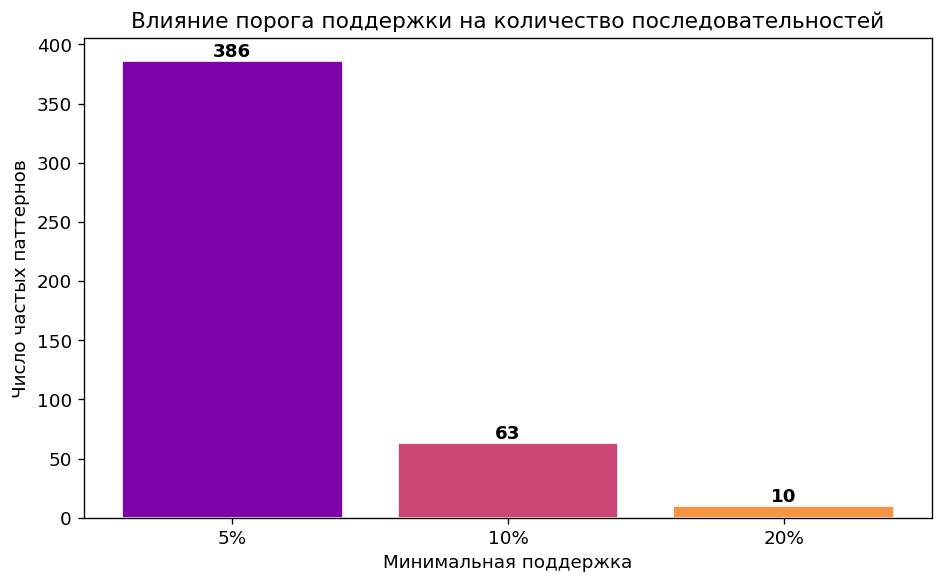


Интерпретация: чем выше порог, тем меньше обнаруживается паттернов.
При низком пороге алгоритм находит экспоненциально больше редких шаблонов,
но время работы существенно возрастает — проявляется проблема комбинаторного взрыва.



In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = [f"{s*100:.0f}%" for s in support_values]
counts = [len(results_vs_support[s]) for s in support_values]
colors = sns.color_palette('plasma', len(counts))
bars = ax.bar(labels, counts, color=colors, edgecolor='white')

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Минимальная поддержка')
ax.set_ylabel('Число частых паттернов')
ax.set_title('Влияние порога поддержки на количество последовательностей')
plt.tight_layout()
plt.show()

print("\nИнтерпретация: чем выше порог, тем меньше обнаруживается паттернов.")
print("При низком пороге алгоритм находит экспоненциально больше редких шаблонов,")
print("но время работы существенно возрастает — проявляется проблема комбинаторного взрыва.\n")

# 2. Сравнение с классическими ассоциативными правилами
Реализуем классический алгоритм Apriori для поиска ассоциативных правил (без учета времени и ID клиентов) и выберем топ-3 правила по метрике Lift.

In [16]:
def classic_apriori(transactions, min_support):
    n = len(transactions)
    min_cnt = max(1, int(min_support * n))

    # Частые 1-элементные наборы
    item_cnt = defaultdict(int)
    for t in transactions:
        for item in t:
            item_cnt[frozenset([item])] += 1
    cur_freq = {it: c for it, c in item_cnt.items() if c >= min_cnt}
    all_freq_sets = {tuple(sorted(k)): v / n for k, v in cur_freq.items()}

    k = 2
    while cur_freq:
        prev = [tuple(sorted(s)) for s in cur_freq.keys()]
        candidates = set()
        for i in range(len(prev)):
            for j in range(i+1, len(prev)):
                union = frozenset(prev[i]) | frozenset(prev[j])
                if len(union) == k:
                    candidates.add(union)
        if not candidates:
            break
        cand_counts = defaultdict(int)
        for t in transactions:
            for c in candidates:
                if c.issubset(t):
                    cand_counts[c] += 1
        cur_freq = {c: cnt for c, cnt in cand_counts.items() if cnt >= min_cnt}
        for c, cnt in cur_freq.items():
            all_freq_sets[tuple(sorted(c))] = cnt / n
        k += 1
    return all_freq_sets

def make_rules(freq_sets, min_conf=0.1):
    rules = []
    for itemset_tup, supp in freq_sets.items():
        itemset = frozenset(itemset_tup)
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for ante_tup in combinations(sorted(itemset), i):
                ante = frozenset(ante_tup)
                cons = itemset - ante
                ante_k = tuple(sorted(ante))
                cons_k = tuple(sorted(cons))
                if ante_k not in freq_sets or cons_k not in freq_sets:
                    continue
                supp_ante = freq_sets[ante_k]
                conf = supp / supp_ante
                if conf < min_conf:
                    continue
                supp_cons = freq_sets[cons_k]
                lift = conf / supp_cons if supp_cons > 0 else float('inf')
                rules.append({
                    'antecedent': ante_tup,
                    'consequent': cons_k,
                    'support': supp,
                    'confidence': conf,
                    'lift': lift
                })
    return rules

**Проверка инверсии порядка в ассоциациях**
Проверим, сохраняется ли зависимость, если поменять местами антецедент и консеквент во времени.

In [17]:
# Строим плоские транзакции "корзины" (без учёта последовательности)
baskets = []
for _, txns in cust_sequences.items():
    for _, items in txns:
        clean = items & set(top_products)
        if clean:
            baskets.append(frozenset(clean))

print(f"Всего плоских транзакций для анализа правил: {len(baskets)}")
itemsets_cl = classic_apriori(baskets, min_support=0.05)
rules_cl = make_rules(itemsets_cl, min_conf=0.1)

top3_lift = sorted(rules_cl, key=lambda r: r['lift'], reverse=True)[:3]
print("\nТоп-3 ассоциативных правила по Lift:")
for i, r in enumerate(top3_lift, 1):
    print(f"  {i}. {set(r['antecedent'])} -> {set(r['consequent'])}  "
          f"s={r['support']:.3f}  c={r['confidence']:.3f}  lift={r['lift']:.2f}")

# Сравнение с последовательностными шаблонами AprioriAll
seq_patterns_005 = results_vs_support.get(0.05, {})
print("\nПроверка поддержки этих правил как направленных последовательностей <{A} -> {B}>:")
for i, r in enumerate(top3_lift, 1):
    for a in r['antecedent']:
        for c in r['consequent']:
            pat_ab = (frozenset([a]), frozenset([c]))
            pat_ba = (frozenset([c]), frozenset([a]))
            sup_ab = seq_patterns_005.get(pat_ab, 0)
            sup_ba = seq_patterns_005.get(pat_ba, 0)
            print(f"  Правило {i}: <{{{a}}} → {{{c}}}> support={sup_ab:.3f} | "
                  f"<{{{c}}} → {{{a}}}> support={sup_ba:.3f}")

print("\nВывод: классические ассоциативные правила полностью игнорируют временной порядок.")
print("Товары, часто покупаемые в одном чеке, далеко не всегда образуют устойчивую временную цепочку.")

Всего плоских транзакций для анализа правил: 12394

Топ-3 ассоциативных правила по Lift:
  1. {'RED HANGING HEART T-LIGHT HOLDER'} -> {'WHITE HANGING HEART T-LIGHT HOLDER'}  s=0.053  c=0.731  lift=3.25
  2. {'WHITE HANGING HEART T-LIGHT HOLDER'} -> {'RED HANGING HEART T-LIGHT HOLDER'}  s=0.053  c=0.237  lift=3.25

Проверка поддержки этих правил как направленных последовательностей <{A} -> {B}>:
  Правило 1: <{RED HANGING HEART T-LIGHT HOLDER} → {WHITE HANGING HEART T-LIGHT HOLDER}> support=0.115 | <{WHITE HANGING HEART T-LIGHT HOLDER} → {RED HANGING HEART T-LIGHT HOLDER}> support=0.122
  Правило 2: <{WHITE HANGING HEART T-LIGHT HOLDER} → {RED HANGING HEART T-LIGHT HOLDER}> support=0.122 | <{RED HANGING HEART T-LIGHT HOLDER} → {WHITE HANGING HEART T-LIGHT HOLDER}> support=0.115

Вывод: классические ассоциативные правила полностью игнорируют временной порядок.
Товары, часто покупаемые в одном чеке, далеко не всегда образуют устойчивую временную цепочку.


# Дополнительное исследование: Ограничение временного разрыва (max_gap)
Проанализируем, как ограничение на максимальное расстояние между покупками (max_gap_days = 7 дней) влияет на количество извлекаемых шаблонов.

In [18]:
print("AprioriAll БЕЗ ограничения по времени (min_sup=10%)...")
t0 = time.time()
no_gap_res = sequence_mining_apriori(cust_sequences, min_sup=0.10)
t_no_gap = time.time() - t0
print(f"  Время: {t_no_gap:.1f} с, паттернов: {len(no_gap_res)}")

print("\nAprioriAll С ограничением max_gap=7 дней (min_sup=10%)...")
t0 = time.time()
gap7_res = sequence_mining_apriori(cust_sequences, min_sup=0.10, max_gap_days=7)
t_gap7 = time.time() - t0
print(f"  Время: {t_gap7:.1f} с, паттернов: {len(gap7_res)}")

only_no_gap = set(no_gap_res.keys()) - set(gap7_res.keys())
only_gap7   = set(gap7_res.keys()) - set(no_gap_res.keys())
common      = set(no_gap_res.keys()) & set(gap7_res.keys())

print(f"\nОбщих паттернов: {len(common)}")
print(f"Присутствуют только без gap: {len(only_no_gap)}")
print(f"Появляются только с gap=7: {len(only_gap7)}")

if only_no_gap:
    print("\nПример шаблона, исчезающего при ограничении в 7 дней:")
    ex = list(only_no_gap)[0]
    ex_str = " → ".join([str(set(s)) for s in ex])
    print(f"  <{ex_str}> (s={no_gap_res[ex]:.3f})")
    print("  Причина: клиенты покупают эти товары последовательно, но с интервалом более недели.")

AprioriAll БЕЗ ограничения по времени (min_sup=10%)...
  Длина 2: найдено 12 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
  Длина 5: найдено 0 частых последовательностей
  Время: 6.7 с, паттернов: 63

AprioriAll С ограничением max_gap=7 дней (min_sup=10%)...
  Длина 2: найдено 0 частых последовательностей
  Время: 9.9 с, паттернов: 49

Общих паттернов: 49
Присутствуют только без gap: 14
Появляются только с gap=7: 0

Пример шаблона, исчезающего при ограничении в 7 дней:
  <{'WHITE HANGING HEART T-LIGHT HOLDER'} → {'RED HANGING HEART T-LIGHT HOLDER'}> (s=0.122)
  Причина: клиенты покупают эти товары последовательно, но с интервалом более недели.


# Визуализация графа переходов покупок
Построим ориентированный граф для топ-15 последовательных паттернов, состоящих из двух шагов. Толщина ребер будет соответствовать уровню поддержки перехода.

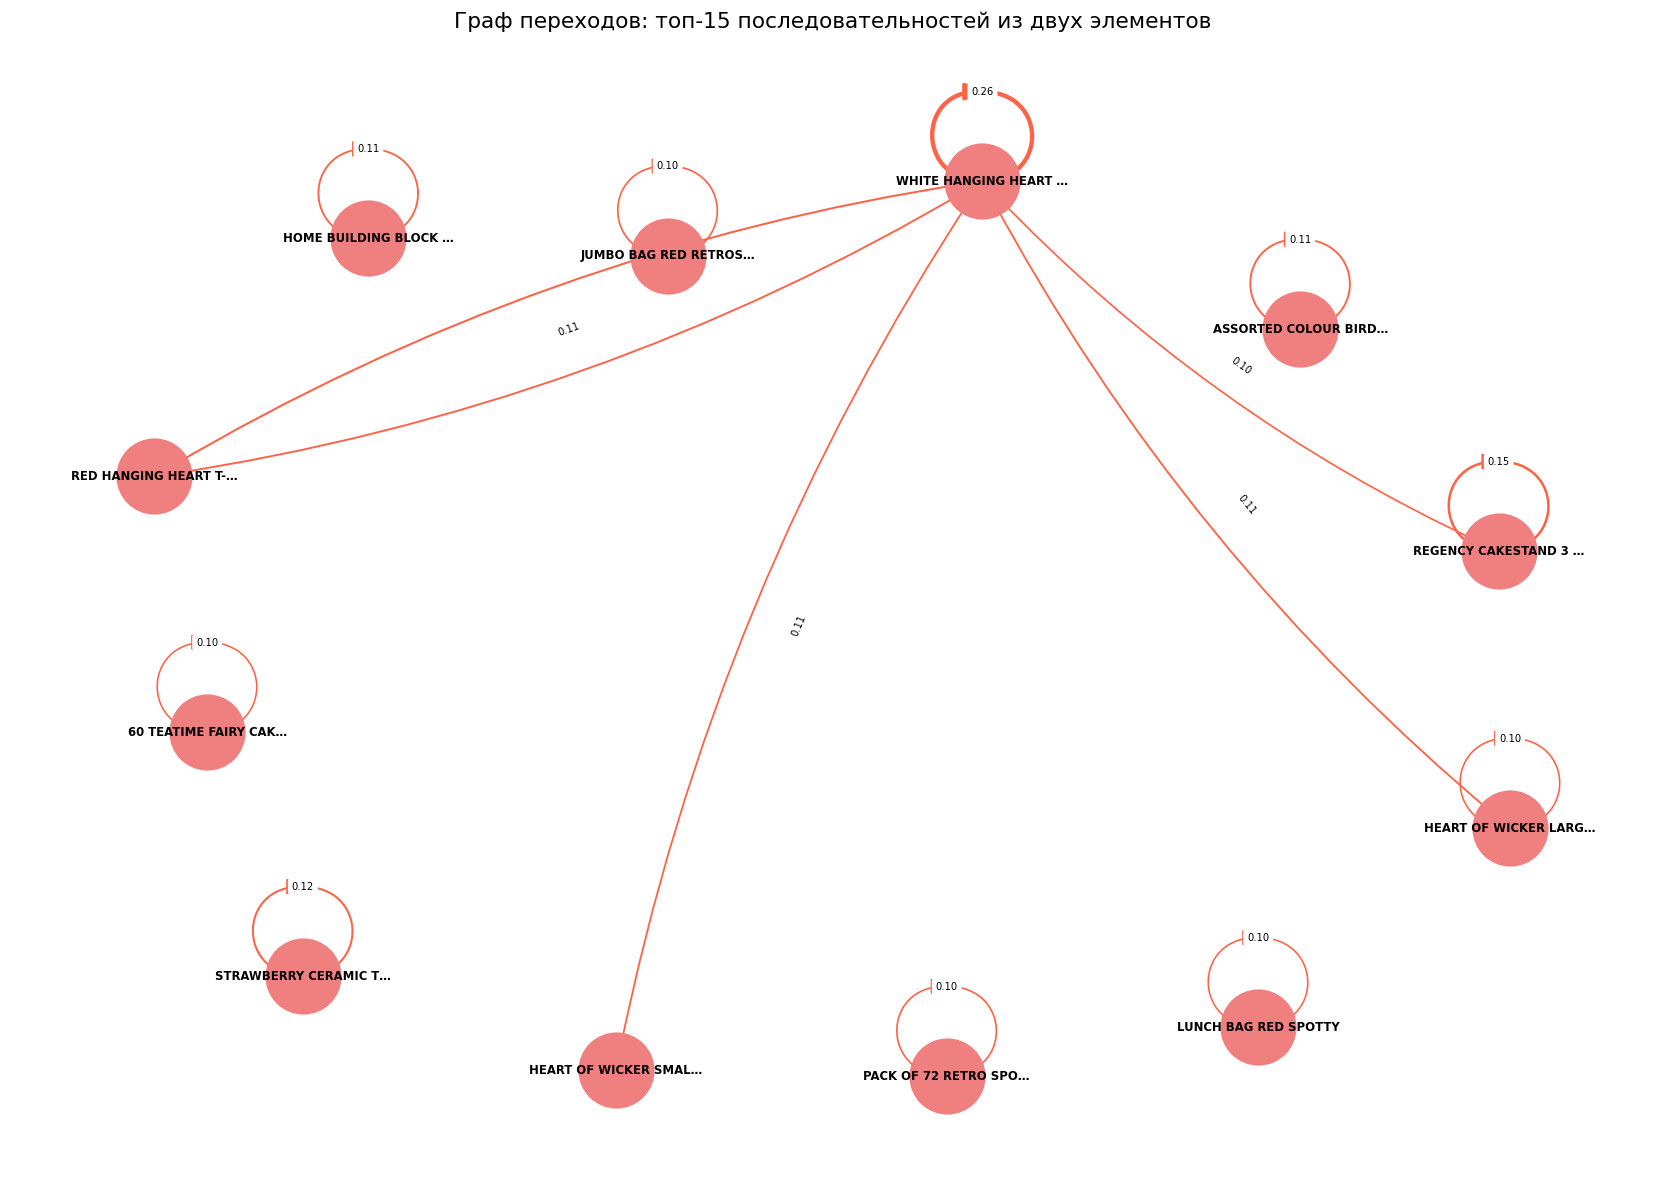


Самый частый переход: <{'WHITE HANGING HEART T-LIGHT HOLDER'} → {'WHITE HANGING HEART T-LIGHT HOLDER'}> (support=0.259)
Бизнес-идея: при покупке первого товара можно сразу рекомендовать второй в интерфейсе.


In [19]:
pairs = {p: s for p, s in seq_patterns_005.items() if len(p) == 2}
if not pairs:
    print("Двухэлементных последовательностей для визуализации не найдено.")
else:
    G = nx.DiGraph()
    for pat, supp in sorted(pairs.items(), key=lambda x: -x[1])[:15]:
        src_items = list(pat[0])
        dst_items = list(pat[1])
        src = src_items[0] if len(src_items)==1 else str(set(pat[0]))
        dst = dst_items[0] if len(dst_items)==1 else str(set(pat[1]))
        src_lbl = src[:20] + '…' if len(str(src))>20 else str(src)
        dst_lbl = dst[:20] + '…' if len(str(dst))>20 else str(dst)
        G.add_edge(src_lbl, dst_lbl, weight=supp)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=2)
    w = [G[u][v]['weight'] * 10 for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_color='lightcoral', node_size=2000)
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
    nx.draw_networkx_edges(G, pos, width=w, edge_color='tomato',
                           arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.1')

    edge_annot = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_annot, font_size=6)
    plt.title('Граф переходов: топ-15 последовательностей из двух элементов')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    best_pat = max(pairs.items(), key=lambda x: x[1])
    best_str = " → ".join([str(set(s)) for s in best_pat[0]])
    print(f"\nСамый частый переход: <{best_str}> (support={best_pat[1]:.3f})")
    print("Бизнес-идея: при покупке первого товара можно сразу рекомендовать второй в интерфейсе.")

# Сравнение эффективности: AprioriAll vs PrefixSpan
Сравним скорость генерации шаблонов нашей ручной реализации AprioriAll и эффективного алгоритма проекции баз данных PrefixSpan из внешней библиотеки.

In [20]:
# Форматирование данных под формат библиотеки PrefixSpan
ps_data = []
for cid, txns in cust_sequences.items():
    order = []
    for _, items in txns:
        order.extend(sorted(items))
    ps_data.append(order)

min_sup_10 = 0.10
min_cnt_ps = max(1, int(min_sup_10 * len(ps_data)))

print(f"Запуск PrefixSpan (min_count={min_cnt_ps}, 10%)...")
start_ps = time.time()
ps_model = PrefixSpan(ps_data)
ps_model.minlen = 1
ps_model.maxlen = 5
freq_ps = ps_model.frequent(min_cnt_ps)
time_ps = time.time() - start_ps
print(f"  Время PrefixSpan: {time_ps:.2f} с, найдено шаблонов: {len(freq_ps)}")

print(f"\nЗапуск нашей реализации AprioriAll (min_sup=10%)...")
start_aa = time.time()
freq_aa = sequence_mining_apriori(cust_sequences, min_sup=min_sup_10)
time_aa = time.time() - start_aa
print(f"  Время AprioriAll: {time_aa:.2f} с, найдено шаблонов: {len(freq_aa)}")

print("\n" + "="*65)
print(f"{'Метод':<15} {'Время (с)':<15} {'Паттернов':<20} {'Примечание'}")
print("-"*65)
print(f"{'AprioriAll':<15} {time_aa:<15.2f} {len(freq_aa):<20} {'наша реализация'}")
print(f"{'PrefixSpan':<15} {time_ps:<15.2f} {len(freq_ps):<20} {'библиотечная версия'}")
print("="*65)

Запуск PrefixSpan (min_count=232, 10%)...
  Время PrefixSpan: 0.46 с, найдено шаблонов: 83

Запуск нашей реализации AprioriAll (min_sup=10%)...
  Длина 2: найдено 12 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
  Длина 5: найдено 0 частых последовательностей
  Время AprioriAll: 5.82 с, найдено шаблонов: 63

Метод           Время (с)       Паттернов            Примечание
-----------------------------------------------------------------
AprioriAll      5.82            63                   наша реализация
PrefixSpan      0.46            83                   библиотечная версия


# Валидация: Задача предсказания следующего товара
Разделим данные хронологически на обучающую и тестовую выборки (соотношение 80/20 по времени транзакций). Построим прогностическую модель на основе парных последовательностей и сравним её точность по метрике Accuracy@1 с бейзлайном — рекомендацией самого популярного товара.

In [21]:
# Определение даты разреза по времени
all_dates = []
for txns in cust_sequences.values():
    for dt, _ in txns:
        all_dates.append(dt)
all_dates.sort()
split_date = all_dates[int(len(all_dates) * 0.8)]
print(f"Дата разреза выборки: {split_date}")

train_seq = {}
test_pairs = {}
for cid, txns in cust_sequences.items():
    train_part = [(dt, it) for dt, it in txns if dt <= split_date]
    test_part  = [(dt, it) for dt, it in txns if dt > split_date]
    if len(train_part) >= 2:
        train_seq[cid] = train_part
    if len(train_part) >= 1 and len(test_part) >= 1:
        test_pairs[cid] = (train_part[-1][1], test_part[0][1])

print(f"Обучающая выборка: {len(train_seq)} клиентов")
print(f"Тестовая выборка: {len(test_pairs)} клиентов")

print("\nОбучение AprioriAll на Train...")
train_patt = sequence_mining_apriori(train_seq, min_sup=0.05)

# Построение прогностических правил
pred_model = {}
for pat, sup in train_patt.items():
    if len(pat) == 2:
        for src in pat[0]:
            for dst in pat[1]:
                if src not in pred_model or sup > pred_model[src][1]:
                    pred_model[src] = (dst, sup)

# Определение глобально частого товара (Бейзлайн)
item_pop = defaultdict(int)
for txns in train_seq.values():
    for _, items in txns:
        for it in items:
            item_pop[it] += 1
most_popular = max(item_pop, key=item_pop.get)

Дата разреза выборки: 2010-10-21 16:29:00
Обучающая выборка: 1955 клиентов
Тестовая выборка: 1266 клиентов

Обучение AprioriAll на Train...
  Длина 2: найдено 302 частых последовательностей
  Длина 3: найдено 31 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
  Длина 5: найдено 1 частых последовательностей


# Расчет метрики качества на тесте
Прогоним тестовые примеры через обе стратегии прогнозирования и выведем итоговую таблицу точности.

In [22]:
hit_seq = 0
hit_base = 0
total_test = 0

for cid, (last, next_basket) in test_pairs.items():
    total_test += 1
    # 1. Последовательный прогноз
    best_candidate = None
    best_supp = -1
    for item in last:
        if item in pred_model:
            pred_item, conf = pred_model[item]
            if conf > best_supp:
                best_supp = conf
                best_candidate = pred_item
    if best_candidate and best_candidate in next_basket:
        hit_seq += 1

    # 2. Глобальный бейзлайн
    if most_popular in next_basket:
        hit_base += 1

acc_seq = hit_seq / max(total_test, 1)
acc_base = hit_base / max(total_test, 1)

print("\n" + "="*50)
print(f"{'Стратегия предсказания':<30} {'Точность Accuracy@1'}")
print("-"*50)
print(f"{'Последовательная модель':<30} {acc_seq:.4f} ({hit_seq}/{total_test})")
print(f"{'Глобально популярный товар':<30} {acc_base:.4f} ({hit_base}/{total_test})")
print("="*50)


Стратегия предсказания         Точность Accuracy@1
--------------------------------------------------
Последовательная модель        0.3712 (470/1266)
Глобально популярный товар     0.1951 (247/1266)


# Задание 5. Контрастные последовательности: High Value против Low Value
Разделим клиентов по общему объему выручки (используем 75-й перцентиль в качестве границы разделения на классы High Value и Low Value). Найдем специфичные паттерны, характерные преимущественно для премиум-сегмента.

In [23]:
# Расчет выручки на клиента
rev = data.groupby('Customer ID').apply(
    lambda g: (g['Quantity'] * g['Price']).sum()
).reset_index()
rev.columns = ['Customer ID', 'revenue']

thresh = rev['revenue'].quantile(0.75)
print(f"Граница разделения (75-й перцентиль): {thresh:.2f}")

high_ids = set(rev[rev['revenue'] >= thresh]['Customer ID'])
low_ids  = set(rev[rev['revenue'] < thresh]['Customer ID'])

high_seqs = {cid: seq for cid, seq in cust_sequences.items() if cid in high_ids}
low_seqs  = {cid: seq for cid, seq in cust_sequences.items() if cid in low_ids}

print(f"High Value класс: {len(high_seqs)} человек | Low Value класс: {len(low_seqs)} человек")

print("\nПоиск паттернов в группе High Value...")
hi_patterns = sequence_mining_apriori(high_seqs, min_sup=0.10)
print("\nПоиск паттернов в группе Low Value...")
lo_patterns = sequence_mining_apriori(low_seqs, min_sup=0.10)

Граница разделения (75-й перцентиль): 298.83
High Value класс: 904 человек | Low Value класс: 1421 человек

Поиск паттернов в группе High Value...
  Длина 2: найдено 316 частых последовательностей
  Длина 3: найдено 95 частых последовательностей
  Длина 4: найдено 9 частых последовательностей
  Длина 5: найдено 1 частых последовательностей

Поиск паттернов в группе Low Value...
  Длина 2: найдено 2 частых последовательностей
  Длина 3: найдено 0 частых последовательностей


# Выделение топ-5 контрастных паттернов и формулировка гипотез
Вычислим разность поддержек (contrast = support(High) - support(Low)) и сформулируем маркетинговые гипотезы.

In [24]:
contrast_list = []
for pat, h_sup in hi_patterns.items():
    l_sup = lo_patterns.get(pat, 0)
    diff = h_sup - l_sup
    contrast_list.append((pat, h_sup, l_sup, diff))

contrast_list.sort(key=lambda x: -x[3])

print("\nТоп-5 характерных для High Value последовательностей:")
print(f"{'Шаблон паттерна':<50} {'HV sup':>8} {'LV sup':>8} {'Контраст'}")
print("-"*83)
for pat, h_s, l_s, diff in contrast_list[:5]:
    pat_vis = " → ".join([str(set(s)) for s in pat])
    print(f"<{pat_vis[:47]:<47}> {h_s:>8.3f} {l_s:>8.3f} {diff:>+10.3f}")

print("\nБизнес-гипотезы:")
for i, (pat, h_s, l_s, diff) in enumerate(contrast_list[:3], 1):
    elements = [list(s)[0] if len(s)==1 else str(set(s)) for s in pat]
    if len(elements) >= 2:
        print(f"  {i}. «Клиенты, покупающие сначала '{elements[0]}', а затем '{elements[1]}',")
        print(f"     с высокой вероятностью перейдут в категорию ценных клиентов High Value» (Δ={diff:+.3f})")


Топ-5 характерных для High Value последовательностей:
Шаблон паттерна                                      HV sup   LV sup Контраст
-----------------------------------------------------------------------------------
<{'WHITE HANGING HEART T-LIGHT HOLDER'} → {'WHIT>    0.325    0.000     +0.325
<{'LUNCH BAG CARS BLUE'}                        >    0.275    0.000     +0.275
<{'REGENCY CAKESTAND 3 TIER'} → {'REGENCY CAKEST>    0.273    0.000     +0.273
<{'WHITE HANGING HEART T-LIGHT HOLDER'} → {'WHIT>    0.420    0.157     +0.263
<{'LUNCH BAG PINK RETROSPOT'}                   >    0.258    0.000     +0.258

Бизнес-гипотезы:
  1. «Клиенты, покупающие сначала 'WHITE HANGING HEART T-LIGHT HOLDER', а затем 'WHITE HANGING HEART T-LIGHT HOLDER',
     с высокой вероятностью перейдут в категорию ценных клиентов High Value» (Δ=+0.325)
  3. «Клиенты, покупающие сначала 'REGENCY CAKESTAND 3 TIER', а затем 'REGENCY CAKESTAND 3 TIER',
     с высокой вероятностью перейдут в категорию ценных клиентов H

# Визуальное сопоставление графов переходов для разных классов клиентов
Построим смежные графы переходов для визуализации различий в поведении ценных и рядовых клиентов интернет-магазина.

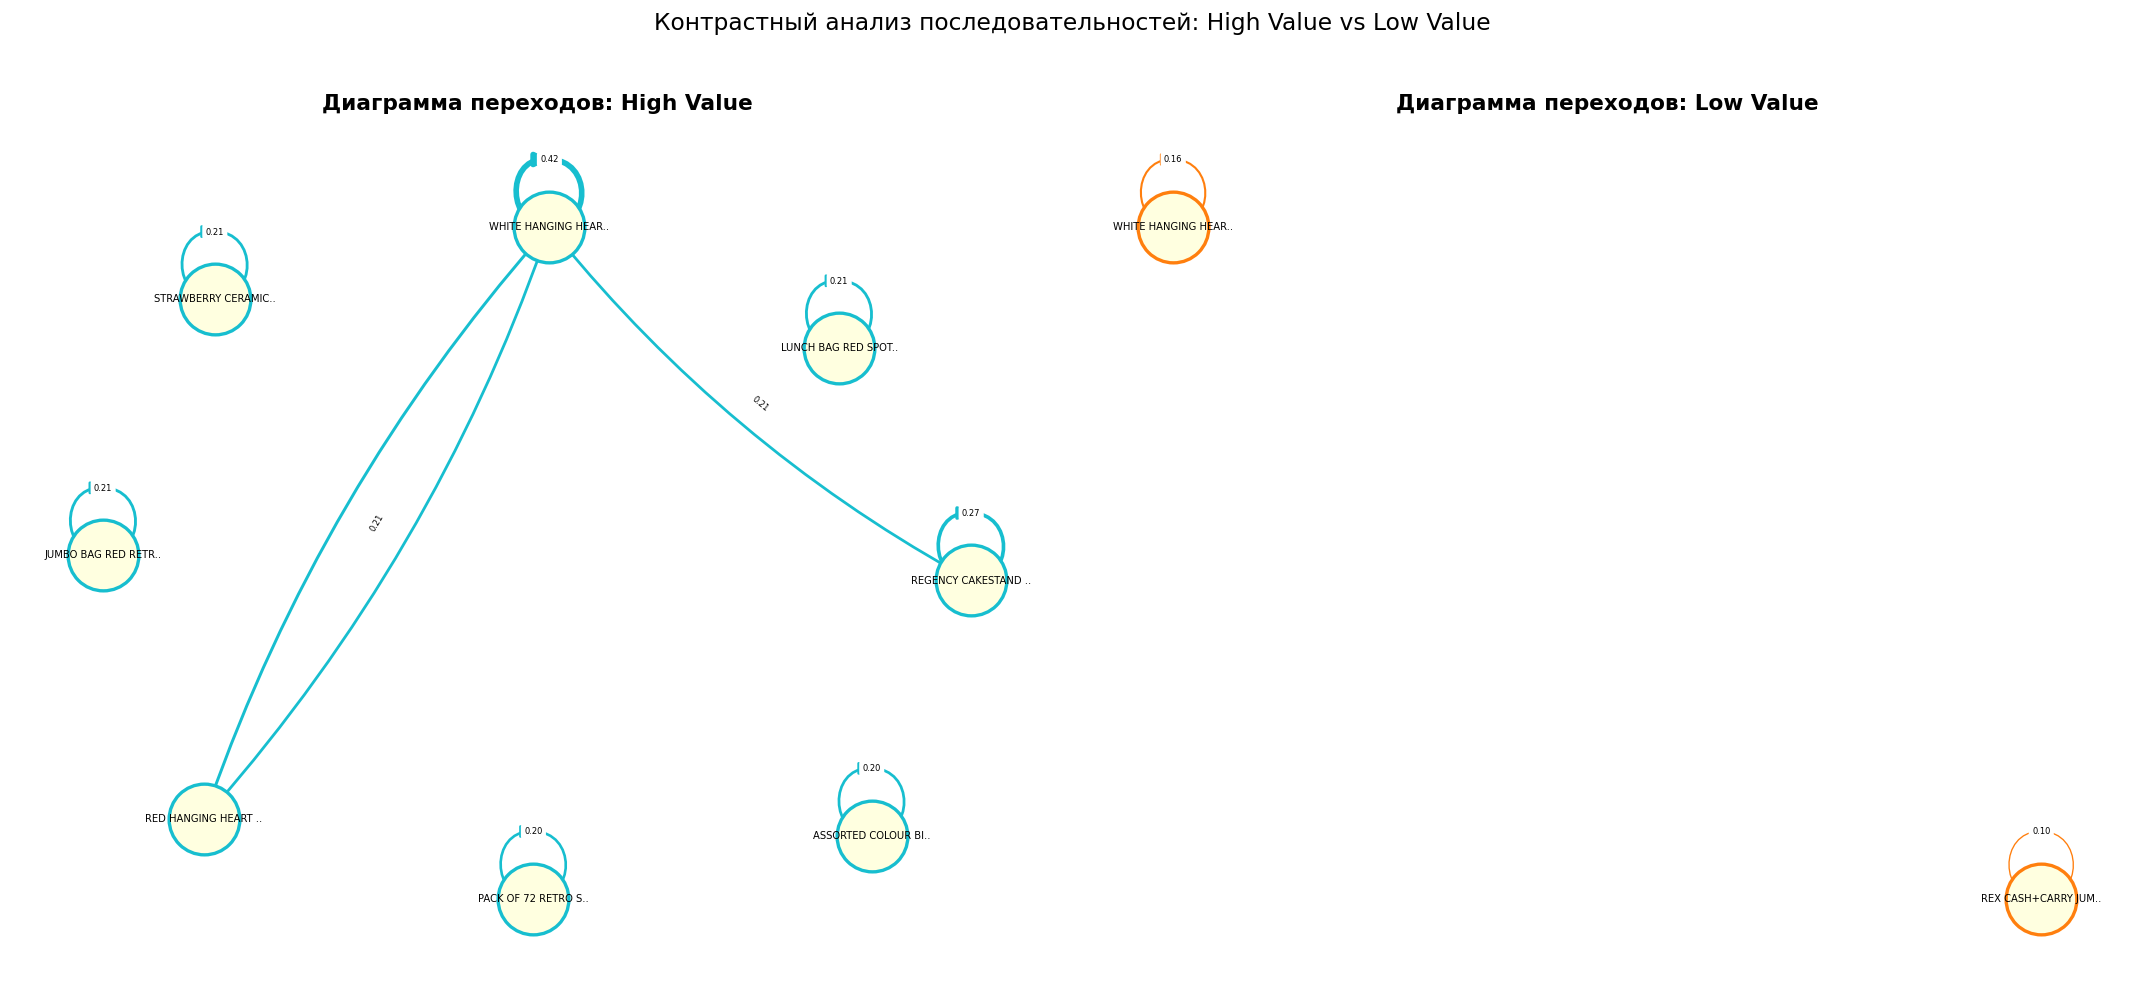

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
color_hv_edge = '#17becf'   # Бирюзовый для ценных клиентов
color_lv_edge = '#ff7f0e'   # Оранжевый для обычных клиентов

for ax, patterns, lbl, clr_edge in [
    (axes[0], hi_patterns, 'High Value', color_hv_edge),
    (axes[1], lo_patterns, 'Low Value',  color_lv_edge)
]:
    pairs_hv = {p: s for p, s in patterns.items() if len(p) == 2}
    G_hv = nx.DiGraph()
    for pat, sup in sorted(pairs_hv.items(), key=lambda x: -x[1])[:10]:
        src = list(pat[0])[0] if len(pat[0])==1 else str(set(pat[0]))
        dst = list(pat[1])[0] if len(pat[1])==1 else str(set(pat[1]))
        s_l = src[:18]+'..' if len(str(src))>18 else str(src)
        d_l = dst[:18]+'..' if len(str(dst))>18 else str(dst)
        G_hv.add_edge(s_l, d_l, weight=sup)

    if G_hv.number_of_nodes() > 0:
        pos = nx.spring_layout(G_hv, seed=42, k=2)
        edge_widths = [G_hv[u][v]['weight'] * 8 for u, v in G_hv.edges()]
        nx.draw_networkx_nodes(G_hv, pos, node_color='lightyellow', node_size=1800,
                               edgecolors=clr_edge, linewidths=2, ax=ax)
        nx.draw_networkx_labels(G_hv, pos, font_size=6, ax=ax)
        nx.draw_networkx_edges(G_hv, pos, width=edge_widths, edge_color=clr_edge,
                               arrows=True, arrowsize=15, connectionstyle='arc3,rad=0.1', ax=ax)
        edge_lbls = {(u,v): f"{G_hv[u][v]['weight']:.2f}" for u,v in G_hv.edges()}
        nx.draw_networkx_edge_labels(G_hv, pos, edge_lbls, font_size=5, ax=ax)

    ax.set_title(f'Диаграмма переходов: {lbl}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Контрастный анализ последовательностей: High Value vs Low Value', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()